# **Strategic Patient Risk Stratification & Readmission Predictive Modeling for Vitality Health Network**

**Team:** Lernaean Hydra

**Team Members:**
- Praveen Rusiru (241722014)
- Harsha Gallage (241722004)
- Ruwani Ranthika (241722021)
- Dinan Themika (241722003)
- Chanuth Dewhan (241722061)

**Date:** January 20, 2026

---

## **Introduction**

This appendix outlines the data processing and analytical workflow for the Vitality Health Network (VHN).

The goal is to analyze historical clinical records and stratify patient risk using the Vitality Complexity Index (VCI). The analysis focuses on identifying key drivers of readmission to inform care strategies and reduce financial penalties associated with high-risk patient cohorts.

In [1]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
import time

# Visualization configuration
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## **Phase 1: Data Ingestion & Inspection**

Load the raw clinical dataset and ID mapping files, then perform initial integrity checks.

**Approach:**
- Ingest `diabetic_data.csv` (clinical records) and `IDs_mapping.csv` (categorical mappings) using `pandas`
- Conduct statistical audit to identify missing values (encoded as `?`), type inconsistencies, and structural anomalies

In [2]:
# Load data
clinical_df = pd.read_csv('../data/diabetic_data.csv')
mapping_df = pd.read_csv('../data/IDs_mapping.csv')

print(f"Clinical Data Shape: {clinical_df.shape}")
print(f"Mapping Data Shape: {mapping_df.shape}")

Clinical Data Shape: (101766, 50)
Mapping Data Shape: (67, 2)


### **1.1 Initial Data Audit**

Inspect data structure, sample records, and statistical distributions to identify potential quality issues early.

In [3]:
clinical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

The dataset contains 101,766 rows and 50 columns. `.info()` shows no nulls, suggesting missing values are encoded as placeholders (likely `?`).

In [4]:
# sample data
clinical_df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


The preview confirms that missing values are represented by the `?` placeholder (visible in columns such as `weight` and `payer_code`). Targeted remediation strategies are required to handle these non-standard nulls.

In [5]:
# Summery stats for numeric columns
clinical_df.describe() 

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


`.describe` is calculating means for categorical IDs (`admission_type_id`, `discharge_dispoistion_id`, `admission_source_id`), which is meaningless. These are nominal variable stores as `int64` and need to be converted to string before modeling.

In [6]:
clinical_df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

50 columns confirmed. Includes medication fields (`metaformin`, `insulin`, etc.) and target variable (`readmitted`)

### **1.2 Schema Standardization**

Convert categorical ID columns to strings to prevent the model from treating them as ordinal variables.

In [7]:
# Convert categorical IDs to string
categorical_ids = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
clinical_df[categorical_ids] = clinical_df[categorical_ids].astype(str)

# Verify conversion
print("Updated Data Types for ID Columns:")
print(clinical_df[categorical_ids].dtypes)

Updated Data Types for ID Columns:
admission_type_id           object
discharge_disposition_id    object
admission_source_id         object
dtype: object


In [8]:
# Replace shorthand 'Ch' with 'Yes' for clarity
clinical_df['change'] = clinical_df['change'].replace('Ch', 'Yes')
print("Standardized 'change' column: Ch --> Yes")

clinical_df['change'].head()

Standardized 'change' column: Ch --> Yes


0     No
1    Yes
2     No
3    Yes
4    Yes
Name: change, dtype: object

### **1.3 Missing Value Analysis**

Identify and handle missing values encoded as `?` Quantify missingness per column to decide whether to drop or impute

In [9]:
# Count `?` placeholder per column
missing_check = (clinical_df == '?').sum()
missing_check = missing_check[missing_check > 0]

# Calculate missingness percentages
missing_percent = (missing_check / len(clinical_df)) * 100

# Summary of the missing check
missing_report = pd.DataFrame({
    'Missing Count': missing_check,
    'Percentage (%)': missing_percent.round(2)
})

missing_report.sort_values('Percentage (%)', ascending=False)

,Missing Count,Percentage (%)
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


In [10]:
# Drop high sparsity columns
columns_to_drop = ['weight', 'payer_code']
clinical_df = clinical_df.drop(columns=columns_to_drop)
print(f"Dropped high-sparsity columns: {columns_to_drop}")

# Replace '?' in 'medical_specialty' to 'Missing' to prevent data loss.
clinical_df['medical_specialty'] = clinical_df['medical_specialty'].replace('?', 'Missing')

# Preserve unmeasured lab test values by mapping NaN to none.
clinical_df['max_glu_serum'] = clinical_df['max_glu_serum'].replace(np.nan, 'None')
clinical_df['A1Cresult'] = clinical_df['A1Cresult'].replace(np.nan, 'None')

# Convert remaining '?' (e.g., in Race, Diagnosis) to NaN, then drop
clinical_df = clinical_df.replace('?', np.nan)

initial_rows = len(clinical_df)
clinical_df = clinical_df.dropna()
dropped_rows = initial_rows - len(clinical_df)

print(f"Rows dropped due to missing data: {dropped_rows}")
print(f"Current Data Shape: {clinical_df.shape}")

Dropped high-sparsity columns: ['weight', 'payer_code']
Rows dropped due to missing data: 3713
Current Data Shape: (98053, 48)


#### Data Quality Decision Log
1. `weight`: Dropped due to 96.8% missing ( exceeding the 90% threshold in the spec.)
2. `payer_code`: Dropped (~40% missing, low clinical relevance)
3. `medical_specialty`: Retained, recoded `?` as `Missing` to preserve categorical information.
4. Remaining nulls in race and diagnosis fields handles via row deletion. 

### **1.4 Domain Logic Filter: Deceased Patients**

Remove patients who `Expired`, as they cannot be readmitted.    
IDs_mapping.csv will be refer to identify which `discharge_disposition_id` values in indicate expired patients, then  exclude those records from dataset.

In [11]:
# Identify expired status codes.
expired_check = mapping_df[mapping_df.iloc[:, 1].str.contains('Expired', case=False, na=False)]
expired_check.columns = ["discharge_disposition_id", "description"]

print("--- Identified 'Expired' Status Codes ---")
expired_check

--- Identified 'Expired' Status Codes ---


,discharge_disposition_id,description
20,11,Expired
28,19,"Expired at home. Medicaid only, hospice."
29,20,"Expired in a medical facility. Medicaid only, ..."
30,21,"Expired, place unknown. Medicaid only, hospice."


`discharge_disposition_id`'s 11, 19, 20 and 21 indicate patients who expired and should be removed from the dataset

In [12]:
# Manually set the identified discharge_disposition_id to removed.
deceased_ids = ['11', '19', '20', '21']

# Check how many records will be removed
deceased_count = clinical_df['discharge_disposition_id'].astype(str).isin(deceased_ids).sum()
print(f"Identified {deceased_count} deceased patient records to be removed.")

# Keep only the rows not in 'deceased_ids'
clinical_df = clinical_df[~clinical_df['discharge_disposition_id'].astype(str).isin(deceased_ids)]

# Reset index filtering
clinical_df.reset_index(drop=True, inplace=True)

print(f"Deceased patients removed. Final Shape: {clinical_df.shape}")

Identified 1616 deceased patient records to be removed.
Deceased patients removed. Final Shape: (96437, 48)


### **1.5 Deduplication Strategy**

Remove exact duplicate rows across all columns. Multiple encounters per patient are valid, but identical rows indicate data entry error.

In [13]:
# Check for duplicates and remove if any exist
duplicate_count = clinical_df.duplicated().sum()

if duplicate_count > 0:
    clinical_df = clinical_df.drop_duplicates()
    print(f"Removed {duplicate_count} duplicate rows.")
else:
    print("No duplicates found.")

print(f"--- PHASE 1 COMPLETE ---")
print(f"Final Analytical Dataset Shape: {clinical_df.shape}")

No duplicates found.
--- PHASE 1 COMPLETE ---
Final Analytical Dataset Shape: (96437, 48)


## **Phase 2: Data Enrichment via Web Scraping**

### **2.1 Target Identification:** 
Identify the top 20 most frequent primary diagnose (`diag_1`) for scraping. Focusing on high frequency codes maximizes contextual value while keeping the process efficient.

In [14]:
# Get top 20 most frequent diagnosis codes.
top_diagnoses = clinical_df['diag_1'].value_counts().head(20)

# Extract codes for scraping
target_codes = top_diagnoses.index.tolist()

print(f"Top 20 Diagnosis Codes identified for scraping: {len(target_codes)}")
print("-" * 50)
print(target_codes)

print("-" * 50)
print("Frequency Table:")

# Display as a dataframe
# top_diagnoses.to_frame(name='Patient_Count')

# Display as a dataframe with better formatting
top_diagnoses_df = top_diagnoses.to_frame(name='Patient_Count').reset_index()
top_diagnoses_df.columns = ['Diagnosis_Code', 'Patient_Count']
top_diagnoses_df.style.hide(axis='index')


Top 20 Diagnosis Codes identified for scraping: 20
--------------------------------------------------
['428', '414', '786', '410', '486', '427', '491', '715', '780', '682', '434', '996', '276', '250.8', '599', '38', '584', 'V57', '250.6', '820']
--------------------------------------------------
Frequency Table:


Diagnosis_Code,Patient_Count
428,6603
414,6349
786,3900
410,3382
486,3320
427,2665
491,2187
715,2069
780,1969
682,1954


### **2.2 Scraper Architecture**

Retrieve the disease names(long description) for target diagnosis codes using an external ICD-9 lookup.
- Use `http://icd9.chrisendres.com` as the source
- Use `requests` and `BeautifulSoup` to fetch and parse data.
- Include 1-second delays between requests to avoid server overload.


In [15]:
def fetch_icd9_description(code):
    """
    Scrapes the ICD-9 description for a given code.
    - Handles padding (38 -> 038).
    - Extract returns the target desc.
    """
    BASE_URL = "http://icd9.chrisendres.com/index.php"
    
    # Pad numeric codes to 3 digits (Website requirement)
    search_term = code.zfill(3) if len(code) < 3 and not code.startswith(('V', 'E')) else code

    params = {
        'action': 'search',
        'srchtext': search_term,
        'srchtype': 'diseases',
        'Submit': 'Search'
    }

    try:
        response = requests.get(BASE_URL, params=params, timeout=10)
        response.raise_for_status()

        soup = BeautifulSoup(response.text, 'html.parser')
            
        # Extract content from target div-'dlvl'
        desc_div = soup.find('div', class_='dlvl')
                
        if desc_div:
            full_text = desc_div.get_text(strip=True)

            # Remove the search term(code) from the result to get only desc.
            clean_desc = full_text.replace(str(search_term), '', 1).strip()                  
            return clean_desc
            
        return "Description Not Found"

    except Exception as e:
        print(f"Error scraping {code}: {e}")
        return "Description Not Found"


print("Starting Web Scraper")
print("-" * 50)

icd_descriptions = {}

for code in target_codes:
    description = fetch_icd9_description(code)    
    icd_descriptions[code] = description
    print(f"Code {code}: {description}")
    
    # 1-second delay between requests
    time.sleep(1)

print("-" * 50)
print("Scraping Complete.")

Starting Web Scraper
--------------------------------------------------
Code 428: Heart failure
Code 414: Other forms of chronic ischemic heart disease
Code 786: Symptoms involving respiratory system and other chest symptoms
Code 410: Acute myocardial infarction
Code 486: Pneumonia, organism unspecified
Code 427: Cardiac dysrhythmias
Code 491: Chronic bronchitis
Code 715: Osteoarthrosis and allied disorders
Code 780: General symptoms
Code 682: Other cellulitis and abscess
Code 434: Occlusion of cerebral arteries
Code 996: Complications peculiar to certain specified procedures
Code 276: Disorders of fluid, electrolyte, and acid-base balance
Code 250.8: Diabetes with other specified manifestations
Code 599: Other disorders of urethra and urinary tract
Code 38: Septicemia
Code 584: Acute renal failure
Code V57: Care involving use of rehabilitation procedures
Code 250.6: Diabetes with neurological manifestations
Code 820: Fracture of neck of femur
------------------------------------------

In [16]:
icd_descriptions

{'428': 'Heart failure',
 '414': 'Other forms of chronic ischemic heart disease',
 '786': 'Symptoms involving respiratory system and other chest symptoms',
 '410': 'Acute myocardial infarction',
 '486': 'Pneumonia, organism unspecified',
 '427': 'Cardiac dysrhythmias',
 '491': 'Chronic bronchitis',
 '715': 'Osteoarthrosis and allied disorders',
 '780': 'General symptoms',
 '682': 'Other cellulitis and abscess',
 '434': 'Occlusion of cerebral arteries',
 '996': 'Complications peculiar to certain specified procedures',
 '276': 'Disorders of fluid, electrolyte, and acid-base balance',
 '250.8': 'Diabetes with other specified manifestations',
 '599': 'Other disorders of urethra and urinary tract',
 '38': 'Septicemia',
 '584': 'Acute renal failure',
 'V57': 'Care involving use of rehabilitation procedures',
 '250.6': 'Diabetes with neurological manifestations',
 '820': 'Fracture of neck of femur'}

### **2.3 Integration**

Map scraped descriptions to the `diag_1` column to create a new column called `Primary_Diagnosis_Desc`. Codes outside the Top 20 will labeled as `Not in Top 20`. If a code belongs in the Top 20 but its descripton not foud then it is labeled as `Description Unavailable`.

In [17]:
# Map scraped diagnosis desc to the df
clinical_df['Primary_Diagnosis_Desc'] = clinical_df['diag_1'].map(icd_descriptions)

# Missing mappings are treated as non-target diagnosis codes(Not in Top 20)
clinical_df['Primary_Diagnosis_Desc'] = clinical_df['Primary_Diagnosis_Desc'].fillna('Not in Top 20')

# Any failed lookups are labeled to differentiate them from non-targets.
clinical_df['Primary_Diagnosis_Desc'] = clinical_df['Primary_Diagnosis_Desc'].replace('Description Not Found', 'Description Unavailable')

print(f"Final Data Shape: {clinical_df.shape}")

Final Data Shape: (96437, 49)


In [18]:
clinical_df[['diag_1', 'Primary_Diagnosis_Desc']]

,diag_1,Primary_Diagnosis_Desc
0,276,"Disorders of fluid, electrolyte, and acid-base..."
1,648,Not in Top 20
2,8,Not in Top 20
3,197,Not in Top 20
4,414,Other forms of chronic ischemic heart disease
...,...,...
96432,250.13,Not in Top 20
96433,560,Not in Top 20
96434,38,Septicemia
96435,996,Complications peculiar to certain specified pr...


## **Phase 3: Exploratory Data Analysis (EDA)**

Explore the data to understand patterns and factors affecting readmissions.

- **Target Distribution:** Check how readmitted is distributed to spot any class imbalance.
- **Demographics:** Look at readmission rates across age, race and gender to find any disparities.
- **Medication Impact:** Compare the effect of insulin vs oral meds on readmission risk.
- **Hospital Metrics:** Examine how operational factors like Length of stay and number of lab procedures related to readmissions.

### **3.1:  The Readmission Landscape**

Examine the distribution of the target variable readmitted to understand class imbalance. The focus is on the <30 group, which represents patients readmitted within 30 days (the HRRP penalty group). This initial check helps determine whether special care is needed in later analysis and modeling due to imbalanced classes.

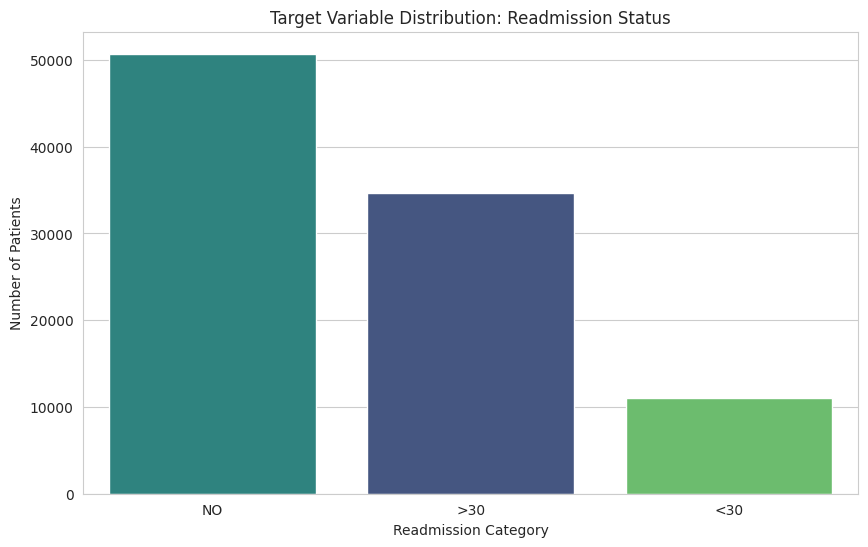

--- Class Imbalance Analysis ---
readmitted
NO     52.60
>30    35.93
<30    11.47
Name: proportion, dtype: float64

Key Insight: The target class '<30' (HRRP Penalty Group) is a minority.
It represents only 11.47% of the population.
This confirms the dataset is imbalanced, requiring careful metric selection later.
--------------------------------------------------


In [19]:
plt.figure()

# Count plot of readmission categories to check class distribution
sns.countplot(
    x='readmitted', 
    data=clinical_df, 
    hue='readmitted', 
    order=['NO', '>30', '<30'], 
    palette='viridis', 
    legend=False
)
plt.title("Target Variable Distribution: Readmission Status")
plt.xlabel("Readmission Category")
plt.ylabel("Number of Patients")
plt.show()

# Calculate the percentage of each class to quantify the imbalance
readmission_rates = clinical_df['readmitted'].value_counts(normalize=True) * 100

print("--- Class Imbalance Analysis ---")
print(readmission_rates.round(2))
print("\nKey Insight: The target class '<30' (HRRP Penalty Group) is a minority.")
print(f"It represents only {readmission_rates['<30']:.2f}% of the population.")
print("This confirms the dataset is imbalanced, requiring careful metric selection later.")
print("-" * 50)

Readmission Class Distribution:

Only 11% of patients were readmitted within 30 days, while most were never readmitted. This imbalance means a model could achieve 90% accuracy by simply predicting "no readmission" for everyone but that defeats the purpose. We need metrics that focus specifically on identifying the high-risk patients who actually get readmitted.

### **3.2:  Demographic Profiling**

Explore how readmission risk varies across patient demographics.

- First, visualize the age distribution to see if diabetes predominantly affects older cohorts in this population.

- Then, analyze readmission rates by race and gender to identify potential intersectional disparities in care outcomes.

These analyses help highlight demographic patterns that may influence readmission risk and guide targeted interventions.

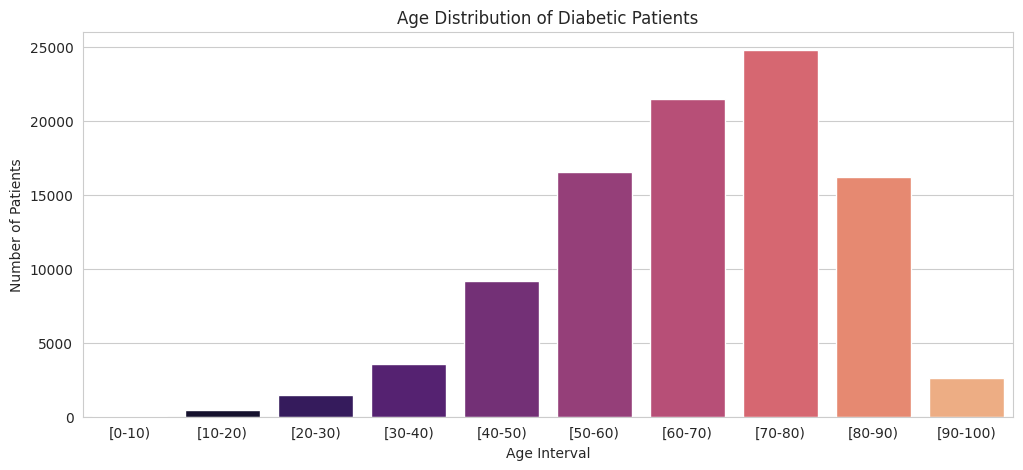

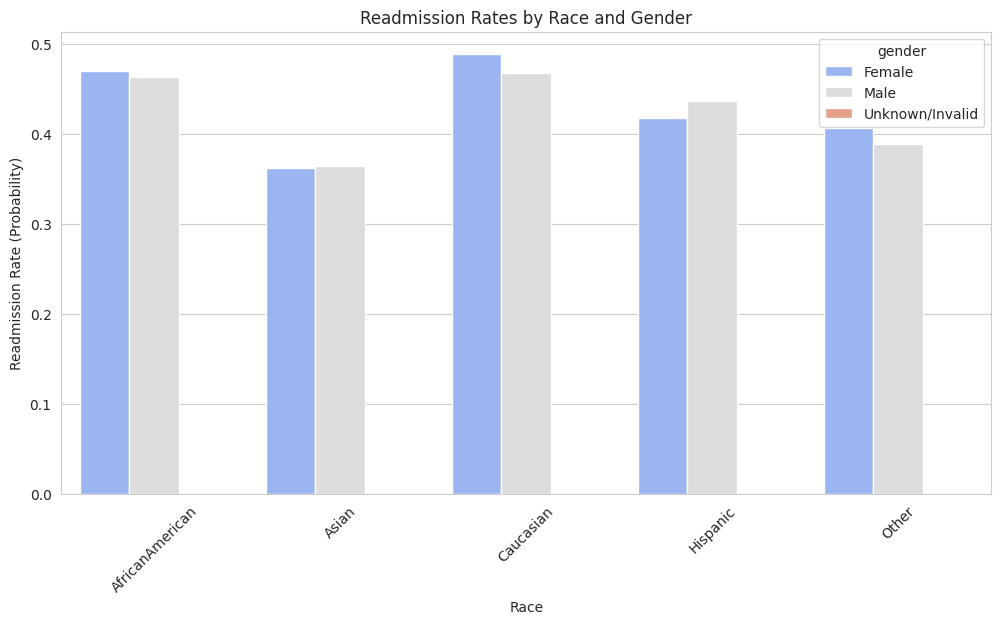

In [20]:
# --- Age Distribution ---

plt.figure(figsize=(12, 5))

# Sort age intervals for proper display
age_order = sorted(clinical_df['age'].unique())

# Visualize how patients are distributed across age groups 
sns.countplot(
    x='age', 
    data=clinical_df, 
    hue='age',
    order=age_order, 
    palette='magma', 
    legend=False
)
plt.title("Age Distribution of Diabetic Patients")
plt.xlabel("Age Interval")
plt.ylabel("Number of Patients")
plt.show()


# --- Readmission Rates by Race & Gender ---

# Create a binary readmission flag for rate calculation
# 1 = readmitted (any type), 0 = not readmitted
clinical_df['has_readmission'] = (clinical_df['readmitted'] != 'NO').astype(int)

# Calculate readmission rates by race and gender
demographic_rates = clinical_df.groupby(['race', 'gender'])['has_readmission'].mean().reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(
    x='race', 
    y='has_readmission', 
    hue='gender', 
    data=demographic_rates, 
    palette='coolwarm'
)
plt.title("Readmission Rates by Race and Gender")
plt.ylabel("Readmission Rate (Probability)")
plt.xlabel("Race")
plt.xticks(rotation=45)
plt.show()

Age Distribution:

- Most patients are between 60-90 years old, with the highest concentration around 70-80. This tells us we're dealing with an older population, which makes sense for diabetes. We'll need to keep this in mind when looking at readmissions - older patients naturally face different health challenges than younger ones.

### **3.3: Medication Efficacy Analysis**

Evaluate the correlation between mediacation regimens and readmission risk, Specifically testinng if insulin dependence serves as proxy for disease serverity

- **Stratify patients into three groups:**
    1. **Insulin (± Oral):** Patients on insulin with or without oral meds
    2. **Oral Only:** Patients using only oral meds
    3. **No Medication:** Patients not prescibed any meds during the encounter

- **Medication Changes:** Check if medication adjustments during hospitalization are correlate with higher readmission rates.

In [21]:
# Identify medication columns in the dataset
print("--- Available Columns for Medication Analysis ---")
print(clinical_df.columns.tolist())

--- Available Columns for Medication Analysis ---
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'Primary_Diagnosis_Desc', 'has_readmission']


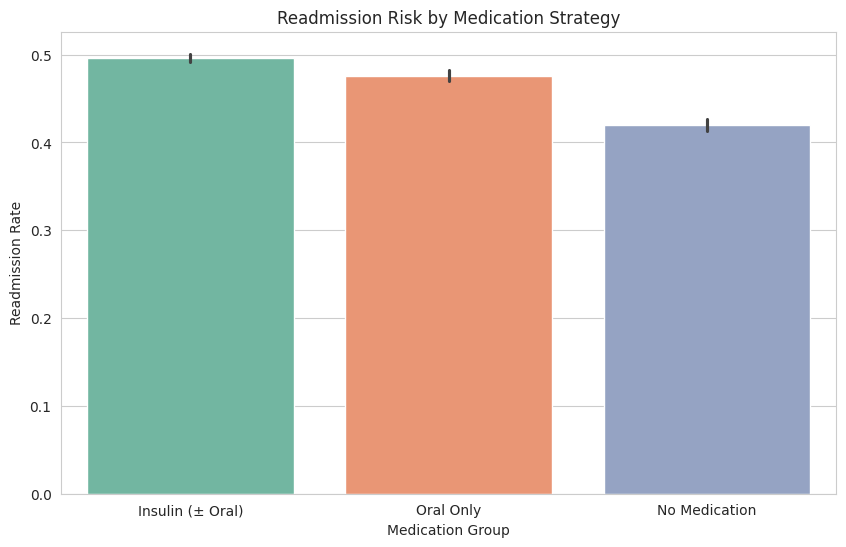

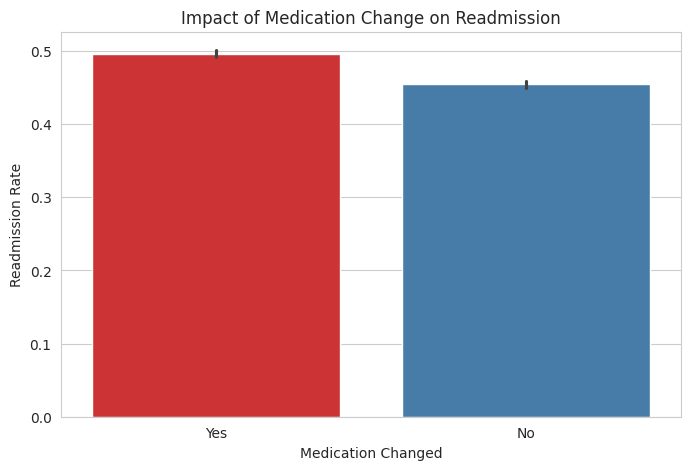

In [22]:
# Define oral medication columns from dataset
oral_meds = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 
    'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 
    'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 
    'glipizide-metformin', 'glimepiride-pioglitazone', 
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

def define_med_status(row):
    """
    Classifies patients into medication risk cohorts.
    Insulin > Oral medications > No Medication.
    """

    on_insulin = row['insulin'] != 'No'
    on_oral = any(row[med] != 'No' for med in oral_meds)
    
    if on_insulin:
        return 'Insulin (± Oral)'
    elif on_oral:
        return 'Oral Only'
    else:
        return 'No Medication'

clinical_df['medication_group'] = clinical_df.apply(define_med_status, axis=1)


# --- Readmission Rate by Medication Group ---

plt.figure(figsize=(10, 6))
sns.barplot(
    x='medication_group', 
    y='has_readmission', 
    data=clinical_df, 
    hue='medication_group',
    palette='Set2', 
    legend=False
)
plt.title("Readmission Risk by Medication Strategy")
plt.xlabel("Medication Group")
plt.ylabel("Readmission Rate")
plt.show()


# --- Impact of medication dosage change ---

plt.figure(figsize=(8, 5))
sns.barplot(
    x='change', 
    y='has_readmission', 
    data=clinical_df, 
    hue='change',
    palette='Set1',
    legend=False 
)
plt.title("Impact of Medication Change on Readmission")
plt.xlabel("Medication Changed")
plt.ylabel("Readmission Rate")
plt.show()

Readmission Risk by Medication Strategy:

- Insulin users have much higher readmission rates (~49%) compared to patients on oral medications or no medication. This makes sense since insulin typically means more advanced diabetes that's harder to control. Plus, managing insulin at home is complicated (injections, dosing, storage), so mistakes can lead patients right back to the hospital. Bottom line: insulin is a red flag for high-risk patients.

### **3.4: Operational Metrics Analysis**

Evaluate hospital resource utilization and discharge planning impact on readmissions. 

1. Analyze correlations between time in hospital and lab procedures
2. Check multicollinearity of numerical features
3. Compare length of stay patterns
4. Assess readmission rates by discharge destination

In [23]:
numerical_cols = clinical_df.select_dtypes(include='integer').columns
numerical_cols

Index(['encounter_id', 'patient_nbr', 'time_in_hospital', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'number_diagnoses',
       'has_readmission'],
      dtype='object')

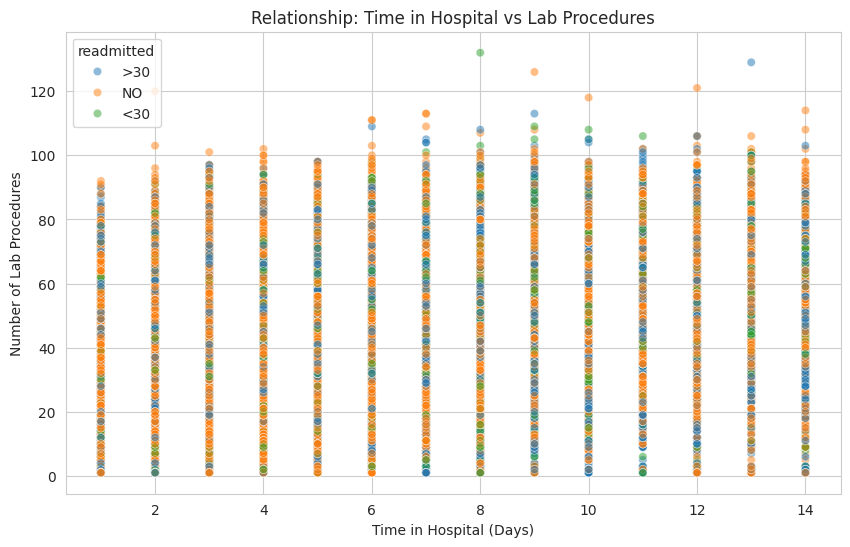

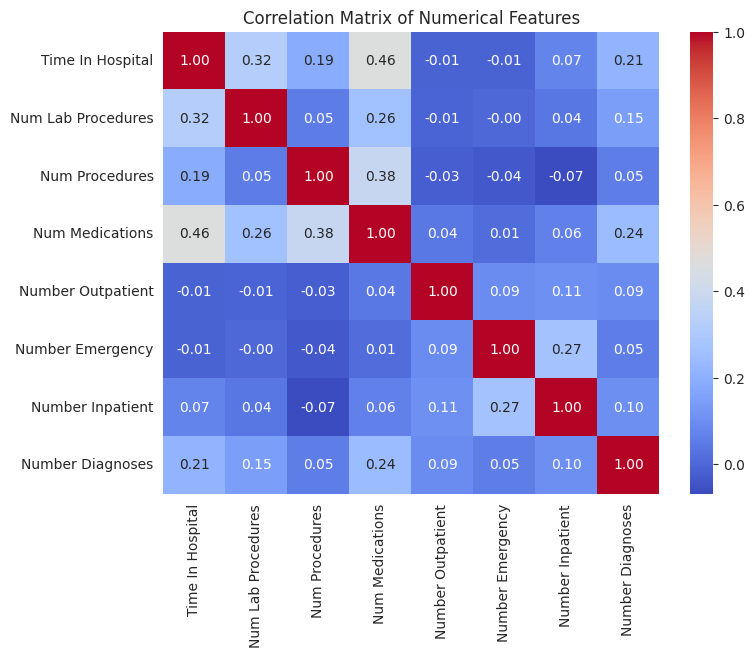

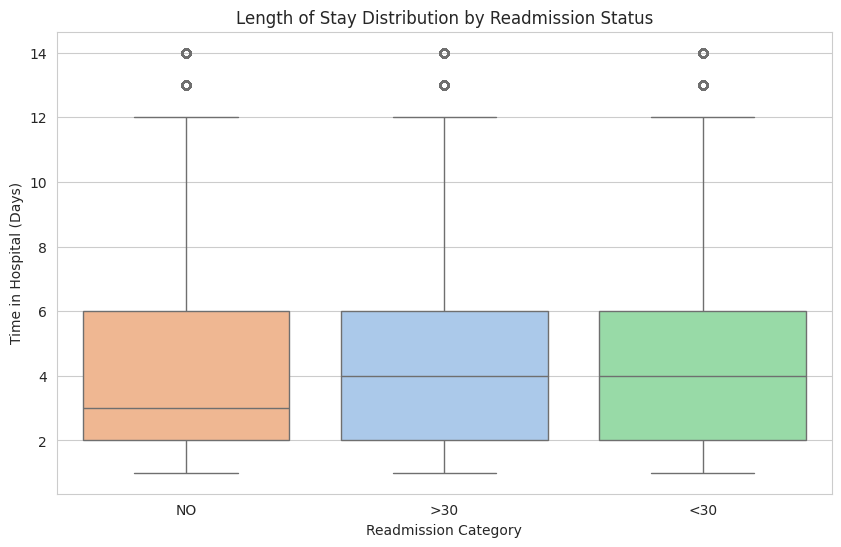

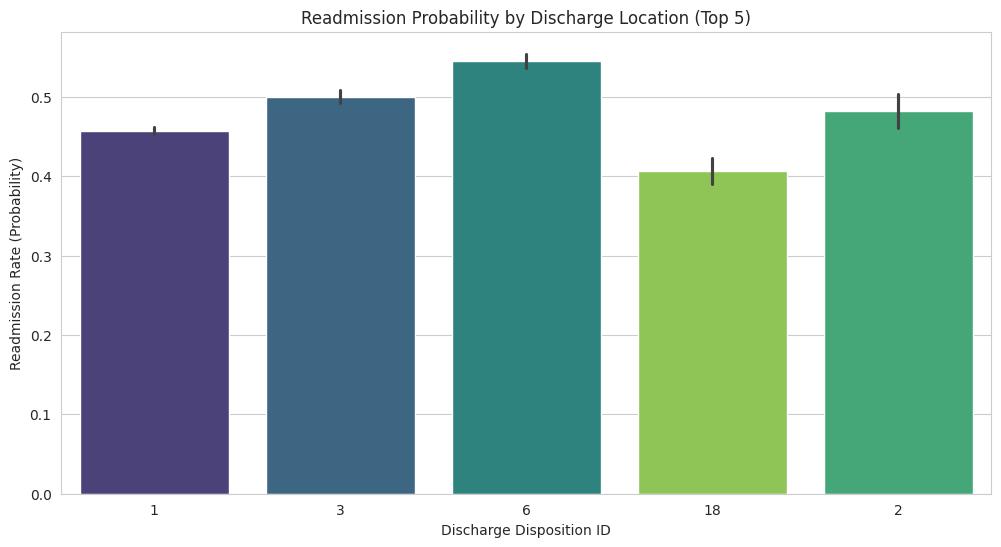

In [24]:
# --- Time in Hospital vs Lab Procedures ---
plt.figure(figsize=(10, 6))

# A scatter plot to check linearity between stay duration and lab usage.
sns.scatterplot(
    x='time_in_hospital', 
    y='num_lab_procedures', 
    hue='readmitted', 
    data=clinical_df, 
    alpha=0.5
)
plt.title("Relationship: Time in Hospital vs Lab Procedures")
plt.xlabel("Time in Hospital (Days)")
plt.ylabel("Number of Lab Procedures")
plt.show()


# --- Correlation matrix of operational numerical metrics ---

plt.figure(figsize=(8, 6))

operational_numeric_cols = [
    'time_in_hospital', 
    'num_lab_procedures', 
    'num_procedures', 
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

corr_matrix = clinical_df[operational_numeric_cols].corr()

heatmap_pretty_labels = [col.replace('_', ' ').title() for col in operational_numeric_cols]

sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f",
    xticklabels=heatmap_pretty_labels,
    yticklabels=heatmap_pretty_labels
)
plt.title("Correlation Matrix of Numerical Features")
plt.show()


# --- Duration in hospital by Readmission Status ---

plt.figure(figsize=(10, 6))

# Box plots to compare stay duration based on readmission categories
sns.boxplot(
    x='readmitted', 
    y='time_in_hospital', 
    data=clinical_df, 
    hue='readmitted',
    order=['NO', '>30', '<30'], 
    palette='pastel', 
)
plt.title("Length of Stay Distribution by Readmission Status")
plt.xlabel("Readmission Category")
plt.ylabel("Time in Hospital (Days)")
plt.show()


# --- Readmission rates by Discharge location ---

# Focus on top 5 most frequent discharge location for clarity
top_discharges = clinical_df['discharge_disposition_id'].value_counts().head(5).index
filtered_discharge = clinical_df[clinical_df['discharge_disposition_id'].isin(top_discharges)]

plt.figure(figsize=(12, 6))

# Bar Plot shows mean readmission rate per discharge location
sns.barplot(
    x='discharge_disposition_id', 
    y='has_readmission', 
    data=filtered_discharge, 
    hue='discharge_disposition_id',
    palette='viridis',
    order=top_discharges,
    legend=False
)
plt.title("Readmission Probability by Discharge Location (Top 5)")
plt.ylabel("Readmission Rate (Probability)")
plt.xlabel("Discharge Disposition ID")
plt.show()

Time in Hospital vs. Lab Procedures:

- There's no clear pattern between how long patients stay and how many lab tests they get. Some patients stay only 2 days but have 80+ lab procedures (very sick, lots of testing), while others stay longer with fewer tests. This tells us lab procedures reflect how sick the patient is, not just how long they're there.

Correlation Matrix:

- No strong correlations between most variables - they each tell us something different. The strongest link is between hospital stay length and number of medications (0.46), which makes sense since longer stays mean more time for medication adjustments. Good news: we don't need to drop any features since they all provide unique information.

Length of Stay by Readmission Status:
- All three groups (NO, <30, >30) show nearly identical hospital stays with a median around 4 days. The boxes overlap heavily, meaning length of stay alone doesn't help us predict who gets readmitted. We'll need more sophisticated features (like our VCI risk score) to actually identify high-risk patients.

Readmission Rates by Discharge Destination:

- Where patients go after discharge matters a lot. Patients sent home with home health services (ID 6) have over 50% readmission rates - higher than those sent to skilled nursing facilities. Interestingly, about 42% of readmitted patients don't have discharge destination recorded, which could indicate gaps in documentation or rushed discharges. This suggests discharge planning is a major factor in preventing readmissions, and we should definitely include discharge destination in any predictive models.

## **Phase 4: Feature Engineering - The "Vitality Complexity Index"**

Create a risk stratification score Vitality Complexity Index(VCI) based on the LACE index framework. The VCI combines Length of stay, acuity of admission, comorbidity count and emergency visits to identify high risk patients.

VCI score stratified into:
- Low Risk: < 7
- Medium Risk: 7–10
- High Risk: > 10

The validity of the index is evaluated by comparing each stratum against the actual <30 day readmission rate.

### **4.1: VCI Score Calculation**

In [25]:
def calculate_L_score(days):
    """ L - Length of Stay Score """
    if days < 1: 
        return 0
    elif 1 <= days <= 4: 
        return 1
    elif 5 <= days <= 13: 
        return 4
    else: 
        return 7  # >= 14 days

def calculate_A_score(admission_id):
    """ A - Acuity of Admission Score (1=Emergency, 7=Trauma) """
    if admission_id in [1, 7]: 
        return 3
    else: 
        return 0

def calculate_C_score(num_diagnoses):
    """ C - Comorbidity Burden Score (Proxy: Count of Diagnoses) """
    if num_diagnoses < 4: 
        return 0
    elif 4 <= num_diagnoses <= 7: 
        return 3
    else: 
        return 5  # >= 8 diagnoses

def calculate_E_score(num_visits):
    """ E - Emergency Visit Intensity Score """
    if num_visits == 0: 
        return 0
    elif 1 <= num_visits <= 4: 
        return 3
    else: 
        return 5  # >4 visits


# Calculate VCI component scores
print("Calculating VCI Components...")
clinical_df['L_score'] = clinical_df['time_in_hospital'].apply(calculate_L_score)
clinical_df['A_score'] = clinical_df['admission_type_id'].apply(calculate_A_score)
clinical_df['C_score'] = clinical_df['number_diagnoses'].apply(calculate_C_score)
clinical_df['E_score'] = clinical_df['number_emergency'].apply(calculate_E_score)

# Calculate Final VCI Score
clinical_df['VCI_Score'] = (clinical_df['L_score'] + 
                            clinical_df['A_score'] + 
                            clinical_df['C_score'] + 
                            clinical_df['E_score'])

print("Sample VCI calculation:")
clinical_df[['L_score', 'A_score', 'C_score', 'E_score', 'VCI_Score']].head()

Calculating VCI Components...
Sample VCI calculation:


,L_score,A_score,C_score,E_score,VCI_Score
0,1,0,5,0,6
1,1,0,3,0,4
2,1,0,3,0,4
3,1,0,3,0,4
4,1,0,5,0,6


### **4.2: Stratification & Analysis:**

In [26]:
def categorize_risk(score):
    """Stratify in to risk categories"""

    if score < 7: 
        return 'Low Risk'
    elif 7 <= score <= 10: 
        return 'Medium Risk'
    else: 
        return 'High Risk'

clinical_df['Risk_Category'] = clinical_df['VCI_Score'].apply(categorize_risk)

# Sample check
print("Feature Engineering Complete. Sample Check:")
clinical_df[['L_score', 'A_score', 'C_score', 'E_score', 'VCI_Score', 'Risk_Category']].head(10)

Feature Engineering Complete. Sample Check:


,L_score,A_score,C_score,E_score,VCI_Score,Risk_Category
0,1,0,5,0,6,Low Risk
1,1,0,3,0,4,Low Risk
2,1,0,3,0,4,Low Risk
3,1,0,3,0,4,Low Risk
4,1,0,5,0,6,Low Risk
5,1,0,3,0,4,Low Risk
6,4,0,5,0,9,Medium Risk
7,4,0,5,0,9,Medium Risk
8,4,0,5,0,9,Medium Risk
9,4,0,5,0,9,Medium Risk


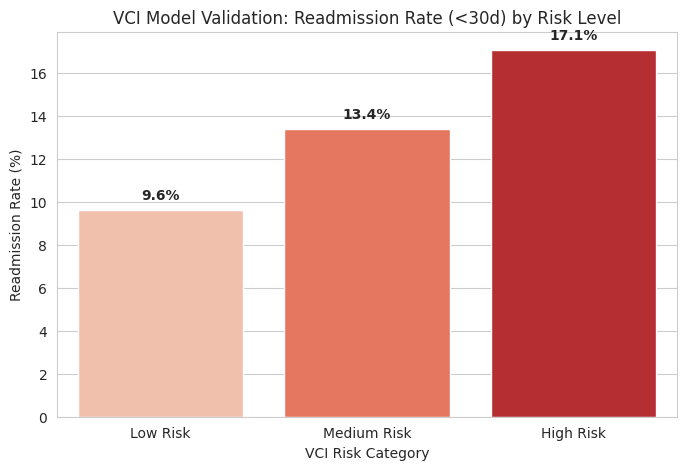

--- Validation Insight ---
Low Risk Readmission Rate:   9.62%
High Risk Readmission Rate:  17.05%
Algorithm Lift: High Risk patients are 1.8x more likely to return.


In [27]:
# Create a binary flag  for <30 day readmissions
clinical_df['is_readmitted_30'] = (clinical_df['readmitted'] == '<30').astype(int)

# Calculate readmission rate per risk category
risk_validation = clinical_df.groupby('Risk_Category')['is_readmitted_30'].mean() * 100

# Ensure the categories appear in logical order: Low -> Med -> High
risk_validation = risk_validation.reindex(['Low Risk', 'Medium Risk', 'High Risk'])

# Visualize validation results
plt.figure(figsize=(8, 5))
sns.barplot(
    x=risk_validation.index, 
    y=risk_validation.values, 
    hue=risk_validation.index ,
    palette='Reds', 
    legend=False 
)

plt.title("VCI Model Validation: Readmission Rate (<30d) by Risk Level")
plt.ylabel("Readmission Rate (%)")
plt.xlabel("VCI Risk Category")

# Annotate bars with actual percentage values
for index, value in enumerate(risk_validation):
    plt.text(index, value + 0.5, f"{value:.1f}%", ha='center', fontweight='bold')

plt.show()

# Display validation metrics
print("--- Validation Insight ---")
print(f"Low Risk Readmission Rate:   {risk_validation['Low Risk']:.2f}%")
print(f"High Risk Readmission Rate:  {risk_validation['High Risk']:.2f}%")
print(f"Algorithm Lift: High Risk patients are {risk_validation['High Risk']/risk_validation['Low Risk']:.1f}x more likely to return.")

The VCI model validation chart shows our risk score actually works. High-risk patients (VCI > 10) have nearly double the readmission rate of low-risk patients - 17% vs 9%. This means we can identify risky patients using simple hospital data without needing complex algorithms. When the VCI flags someone as high-risk, it's worth paying attention to.

In [28]:
# Export final analytical dataset
clinical_df.to_csv('../data/final_diabetes_analysis_VCI.csv', index=False)

print("PROJECT COMPLETED. \nFinal dataset exported successfully.")
print(f"Rows: {clinical_df.shape[0]}, Columns: {clinical_df.shape[1]}")

PROJECT COMPLETED. 
Final dataset exported successfully.
Rows: 96437, Columns: 58
